# 04 — Visual Review & Final Sample

Stage 4 of 5. Documents the SED + template-overlay methodology used to visually vet the 34
candidates from [03 — UV-Excess Selection](03_uv_excess_selection.ipynb), shows representative
examples, and loads the resulting 29-QSO final sample.

**Pipeline:** [01 — Crossmatch](01_crossmatch.ipynb) → [02 — Merge & Dedupe](02_merge_and_dedupe.ipynb)
→ [03 — UV-Excess Selection](03_uv_excess_selection.ipynb) → **04 — Visual Review & Final Sample**
→ [05 — Control Sample](05_control_sample.ipynb)

**Methodology:** for each candidate, 18-band photometry (FUV/NUV/griz/y/UKIDSS-YJHK/2MASS-JHK/
WISE-W1-4) is converted to F_λ and compared against the intrinsic QSO template
(`templates/qso_template.txt`) redshifted to the candidate's z and scaled by the median
observed/synthetic-photometry flux ratio (via `synphot`). **This is a visual scaling, not an
E(B-V) fit** -- `quasar_unred.find_ebv` is never called anywhere in this repo (open item, see
CLAUDE.md known issues).

**The Accept/Reject decision itself is an interactive, human-in-the-loop step, already completed**
by the user via `scripts/seds/review_uv_excess_sample.py`. That script opens a blocking Tkinter
GUI (Accept/Reject buttons) and **cannot run inside a notebook cell** -- if a candidate ever needs
re-review, run it standalone from a terminal:

```
python scripts/seds/review_uv_excess_sample.py
```

It writes decisions incrementally to `data/matched/UV_EXCESS_SAMPLE_progress.csv` and, once all
34 candidates are reviewed, the accepted subset to `data/matched/UV_EXCESS_SAMPLE.csv`. This
notebook loads those two files rather than regenerating them.

**Inputs:** `data/matched/uv_excess_candidates_w2m.csv`, `data/matched/UV_EXCESS_SAMPLE_progress.csv`,
`data/matched/UV_EXCESS_SAMPLE.csv`, `data/matched/FINAL_COMBINED_QSOs_W2M.csv`,
`templates/qso_template.txt`, `data/filters/*.dat`

**Script references:** `scripts/seds/review_uv_excess_sample.py`, `uv_excess_review_report.py`,
`scripts/colorcolor/z_w4_scatter.py`

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import ascii
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

import synphot
from synphot import SourceSpectrum
from synphot import units as su
from synphot import SpectralElement
from synphot.models import Empirical1D
from synphot.observation import Observation

BASE_DIR = Path.cwd().parent
with open(BASE_DIR / "config" / "qso_params.yaml") as f:
    PARAMS = yaml.safe_load(f)

DATA_MATCHED = BASE_DIR / "data" / "matched"
FILTDIR = BASE_DIR / "data" / "filters"
TEMPLATE_QSO = BASE_DIR / "templates" / "qso_template.txt"
FIGURES_DIR = BASE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CAND_CSV = DATA_MATCHED / "uv_excess_candidates_w2m.csv"
PROGRESS_CSV = DATA_MATCHED / "UV_EXCESS_SAMPLE_progress.csv"
SAMPLE_CSV = DATA_MATCHED / "UV_EXCESS_SAMPLE.csv"


def mag_arr(col):
    if hasattr(col, 'filled'):
        return np.array(col.filled(np.nan), dtype=float)
    arr = np.array(col, dtype=str)
    arr[arr == '--'] = 'nan'
    return arr.astype(float)

## SED + template-overlay plotting

Source: `scripts/seds/uv_excess_review_report.py` -- the non-interactive companion to the review
tool (its `plot_sed`/`annotate_status`), safe to run in a notebook. Rewired here to load
wavelengths and Vega→AB offsets from config (including the 2MASS entries added alongside this
notebook rebuild) instead of hardcoding them.

In [2]:
table = Table.read(CAND_CSV, format='csv')

_spec = ascii.read(str(TEMPLATE_QSO))
templateWave = _spec['col1']
templateFlux = _spec['col2']

WL = PARAMS["band_wavelengths_AA"]
WL_2MASS = PARAMS["band_wavelengths_2mass_AA"]
VEGA_AB = PARAMS["vega_to_ab_offsets"]
VEGA_AB_2MASS = PARAMS["vega_to_ab_offsets_2mass"]
FLAM_MAX_GALEX_PS1 = PARAMS["flux_outlier_thresholds_flam"]["galex_panstarrs"] * su.FLAM
FLAM_MAX_UKIDSS = PARAMS["flux_outlier_thresholds_flam"]["ukidss"] * su.FLAM

# (label, mag_col, wavelength_AA, vega_offset, flux_ceiling) -- sorted by wavelength so the
# connecting line in plot_sed() doesn't zigzag. WISE wavelengths come from config (33680 etc.),
# a harmless standardization vs. this script's own slightly different literals (33526 etc.).
BANDS = [
    ('FUV', 'FUVmag', WL['FUV'], 0.0, FLAM_MAX_GALEX_PS1),
    ('NUV', 'NUVmag', WL['NUV'], 0.0, FLAM_MAX_GALEX_PS1),
    ('g', 'gmag', WL['g'], 0.0, FLAM_MAX_GALEX_PS1),
    ('r', 'rmag', WL['r'], 0.0, FLAM_MAX_GALEX_PS1),
    ('i', 'imag', WL['i'], 0.0, FLAM_MAX_GALEX_PS1),
    ('z', 'zmag', WL['z'], 0.0, FLAM_MAX_GALEX_PS1),
    ('y', 'ymag', WL['y'], 0.0, FLAM_MAX_GALEX_PS1),
    ('Y_uk', 'yAperMag3', WL['Y'], VEGA_AB['Y'], FLAM_MAX_UKIDSS),
    ('J_2m', 'Jmag', WL_2MASS['J'], VEGA_AB_2MASS['J'], FLAM_MAX_UKIDSS),
    ('J_uk', 'j_1AperMag3', WL['J'], VEGA_AB['J'], FLAM_MAX_UKIDSS),
    ('H_uk', 'hAperMag3', WL['H'], VEGA_AB['H'], FLAM_MAX_UKIDSS),
    ('H_2m', 'Hmag', WL_2MASS['H'], VEGA_AB_2MASS['H'], FLAM_MAX_UKIDSS),
    ('K_2m', 'Kmag', WL_2MASS['K'], VEGA_AB_2MASS['K'], FLAM_MAX_UKIDSS),
    ('K_uk', 'kAperMag3', WL['K'], VEGA_AB['K'], FLAM_MAX_UKIDSS),
    ('W1', 'W1mag', WL['W1'], VEGA_AB['W1'], FLAM_MAX_UKIDSS),
    ('W2', 'W2mag', WL['W2'], VEGA_AB['W2'], FLAM_MAX_UKIDSS),
    ('W3', 'W3mag', WL['W3'], VEGA_AB['W3'], FLAM_MAX_UKIDSS),
    ('W4', 'W4mag', WL['W4'], VEGA_AB['W4'], FLAM_MAX_UKIDSS),
]

FILT_FILES = [
    "GALEX_GALEX.FUV.dat", "GALEX_GALEX.NUV.dat",
    "PAN-STARRS_PS1.g.dat", "PAN-STARRS_PS1.r.dat", "PAN-STARRS_PS1.i.dat",
    "PAN-STARRS_PS1.z.dat", "PAN-STARRS_PS1.y.dat",
    "UKIRT_UKIDSS.Y.dat", "UKIRT_UKIDSS.J.dat", "UKIRT_UKIDSS.H.dat", "UKIRT_UKIDSS.K.dat",
    "2MASS_2MASS.J.dat", "2MASS_2MASS.H.dat", "2MASS_2MASS.Ks.dat",
    "WISE_WISE.W1.dat", "WISE_WISE.W2.dat", "WISE_WISE.W3.dat", "WISE_WISE.W4.dat",
]
_filter_bandpasses = [SpectralElement.from_file(str(FILTDIR / ff)) for ff in FILT_FILES]

X_LO, X_HI = 1000, 15000


def target_name(index):
    """Stable per-row identifier: designation if present, else TARGETID."""
    desig = str(table['designation'][index])
    if desig not in ('', '--', 'nan', 'None'):
        return desig
    return f"TARGETID_{table['TARGETID'][index]}"


def pick(index, col_a, col_b):
    a = mag_arr(table[col_a])[index]
    return a if np.isfinite(a) else mag_arr(table[col_b])[index]


def candidate_redshift(index):
    z_desi = mag_arr(table['Z'])[index]
    return z_desi if np.isfinite(z_desi) else mag_arr(table['zsp'])[index]


def band_flam(index):
    lam_all, flam_all = [], []
    for _, col, lam, offset, ceiling in BANDS:
        mag = mag_arr(table[col])[index] + offset
        flam = (mag * u.ABmag).to(su.FLAM, u.spectral_density(lam * u.AA))
        if flam > ceiling:
            flam = np.nan * su.FLAM
        lam_all.append(lam)
        flam_all.append(flam.value)
    return np.array(lam_all), np.array(flam_all)


def plot_sed(ax, index):
    ax.clear()
    zsp = candidate_redshift(index)
    lam_all, flam_all = band_flam(index)

    ax.plot(lam_all / (1 + zsp), flam_all, marker='o', linestyle='-', label=target_name(index))

    sp = SourceSpectrum(Empirical1D, points=templateWave * u.AA,
                         lookup_table=templateFlux * su.FLAM, z=zsp)
    synth_flx = []
    for bp in _filter_bandpasses:
        try:
            obs = Observation(sp, bp, force='extrap')
            synth_flx.append(obs.effstim('flam').value)
        except (synphot.exceptions.DisjointError, synphot.exceptions.SynphotError):
            synth_flx.append(np.nan)
    synth_flx = np.array(synth_flx)

    valid = np.isfinite(flam_all) & np.isfinite(synth_flx) & (synth_flx > 0)
    scale = np.nanmedian(flam_all[valid] / synth_flx[valid]) if valid.any() else 1.0
    ax.plot(templateWave, scale * templateFlux, color='gray', alpha=0.6, label='QSO template')

    lam_rest = lam_all / (1 + zsp)
    in_window = np.isfinite(flam_all) & (lam_rest >= X_LO) & (lam_rest <= X_HI)
    y_hi = flam_all[in_window].max() * 1.1 if in_window.any() else 3e-17

    ax.set_xlim(X_LO, X_HI)
    ax.set_ylim(0, y_hi)
    ax.set_xlabel('Rest-frame Wavelength (Å)')
    ax.set_ylabel(r'$F_\lambda$ (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)')
    ra, dec, ebv = pick(index, 'RA', 'ra'), pick(index, 'DEC', 'dec'), pick(index, 'EBV', 'ebv')
    ax.set_title(f"{target_name(index)}\nRA = {ra:.4f}   DEC = {dec:.4f}   z = {zsp:.3f}   E(B-V) = {ebv:.3f}")
    ax.legend(fontsize=8)


STATUS_STYLE = {'YES': ("ACCEPTED", "#2e7d32"), 'NO': ("REJECTED", "#c62828")}


def annotate_status(ax, decision):
    label, color = STATUS_STYLE.get(decision, ("NOT YET REVIEWED", "#757575"))
    ax.text(0.98, 0.95, label, transform=ax.transAxes, ha='right', va='top', fontsize=13,
            fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.85))

## Load candidates + Accept/Reject decisions

In [3]:
decisions = {}
if PROGRESS_CSV.exists():
    decisions = pd.read_csv(PROGRESS_CSV, index_col='designation')['ACCEPTED'].to_dict()

n_yes = sum(1 for v in decisions.values() if v == 'YES')
n_no = sum(1 for v in decisions.values() if v == 'NO')
print(f"{len(table)} candidates, {len(decisions)} reviewed ({n_yes} accepted, {n_no} rejected)")

34 candidates, 34 reviewed (29 accepted, 5 rejected)


## Representative examples

Renders 2 accepted + 2 rejected SEDs inline (highest/lowest E(B-V) within each group, chosen at
runtime rather than hardcoded designations). The complete 34-candidate gallery already exists at
`data/matched/uv_excess_review_report.pdf` -- regenerate anytime with
`python scripts/seds/uv_excess_review_report.py`.

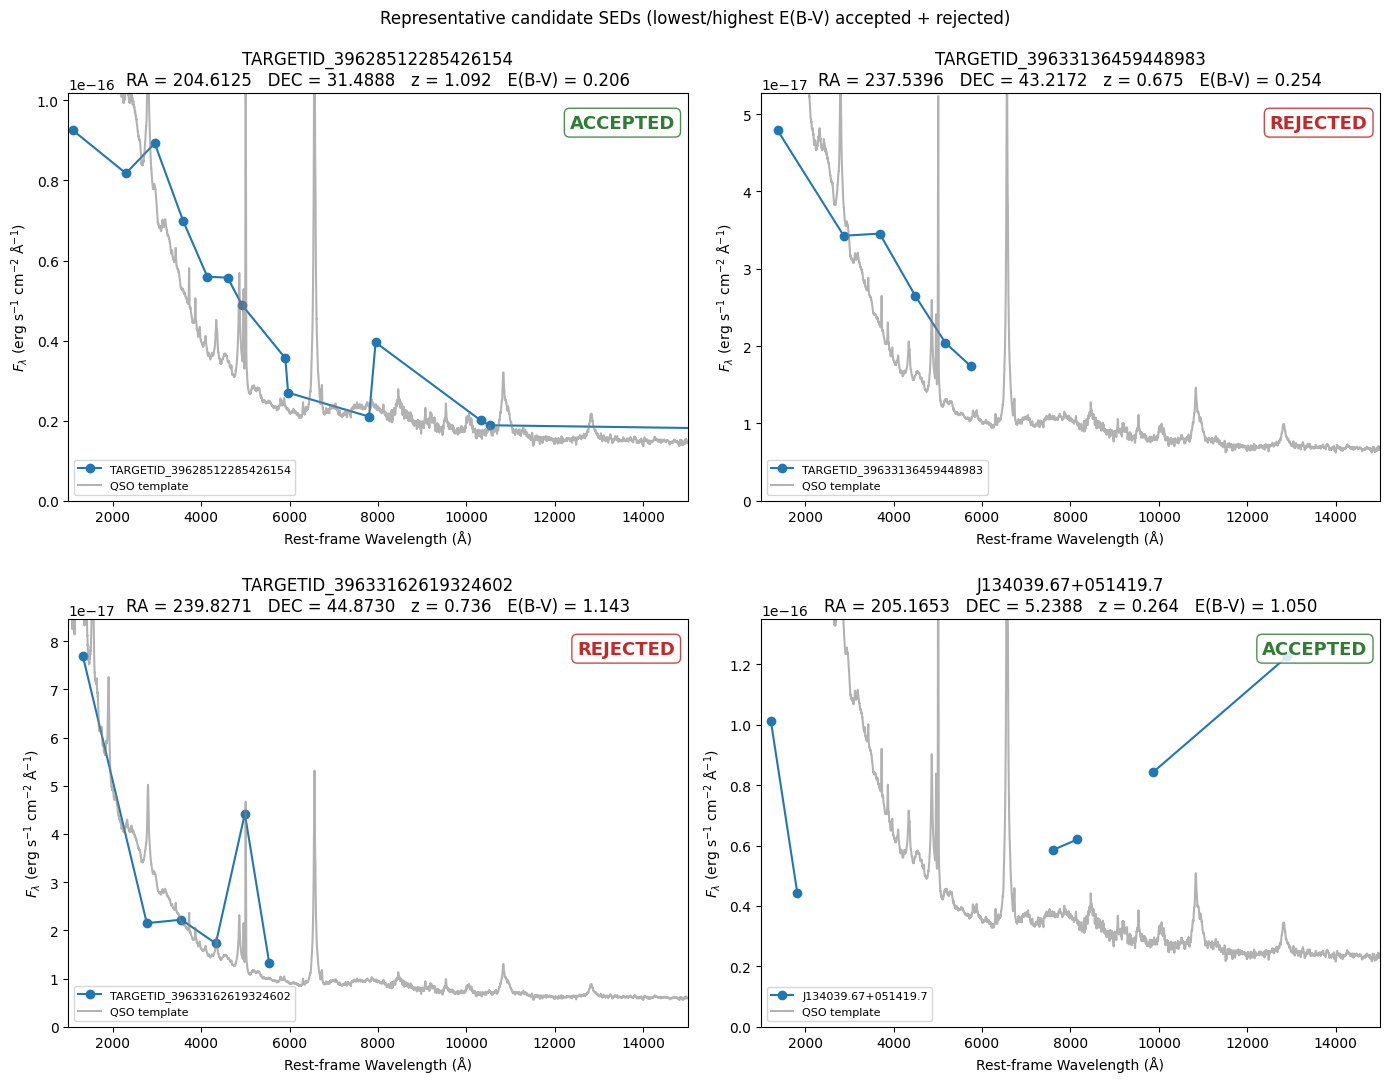

In [4]:
ebv_by_index = {i: pick(i, 'EBV', 'ebv') for i in range(len(table))}
accepted_idx = [i for i in range(len(table)) if decisions.get(target_name(i)) == 'YES']
rejected_idx = [i for i in range(len(table)) if decisions.get(target_name(i)) == 'NO']

examples = []
if accepted_idx:
    examples += sorted(accepted_idx, key=lambda i: ebv_by_index[i])[:1]
    examples += sorted(accepted_idx, key=lambda i: -ebv_by_index[i])[:1]
if rejected_idx:
    examples += sorted(rejected_idx, key=lambda i: ebv_by_index[i])[:1]
    examples += sorted(rejected_idx, key=lambda i: -ebv_by_index[i])[:1]
examples = sorted(set(examples))

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, idx in zip(axes.flat, examples):
    plot_sed(ax, idx)
    annotate_status(ax, decisions.get(target_name(idx)))
for ax in axes.flat[len(examples):]:
    ax.set_visible(False)
fig.suptitle('Representative candidate SEDs (lowest/highest E(B-V) accepted + rejected)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sed_review_examples.png", dpi=150)
plt.show()

## Final sample

Loaded directly from `data/matched/UV_EXCESS_SAMPLE.csv` -- **not regenerated**, since producing
it requires the manual interactive review step above.

In [5]:
final_sample = pd.read_csv(SAMPLE_CSV)
print(f"Final vetted UV-excess sample: {len(final_sample)} QSOs")
final_sample

Final vetted UV-excess sample: 29 QSOs


,TARGETID,RA,DEC,Z,SPECTYPE,EBV,EBV_ERR,FUVmag,NUVmag,gmag,...,FIRST_peak,FIRST_int,VLASS_peak,VLASS_int,broad,src,gmag_2,rmag_2,imag_2,zmag_2
0,3.962835e+16,193.991393,23.848993,0.975600,QSO,0.668677,0.000000,NaN,22.789000,21.735399,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.962838e+16,196.265239,25.143506,0.688700,QSO,0.690726,0.000000,NaN,22.580700,21.624300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.962851e+16,204.612497,31.488779,1.091782,QSO,0.206308,0.000000,NaN,20.865000,19.399700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.962852e+16,153.762446,31.705541,0.531911,QSO,0.265325,0.003739,22.010599,21.025900,19.722500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.963295e+16,253.406357,33.323863,1.051283,QSO,0.218409,0.003948,NaN,22.642799,21.260900,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3.963315e+16,235.672616,44.041677,1.265667,QSO,0.208356,0.000000,NaN,21.705099,20.379700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,3.963327e+16,168.108154,51.313657,0.663485,QSO,0.348460,0.000000,NaN,21.462900,20.252399,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,3.963331e+16,182.543232,54.324658,0.998178,QSO,0.261924,0.000000,NaN,22.085699,21.273800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,3.963333e+16,184.769839,55.358008,1.047300,QSO,0.284462,0.000000,22.528299,22.144699,20.419399,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,3.963333e+16,244.087715,55.272483,0.932485,QSO,0.386380,0.004516,NaN,22.247900,20.830200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Redshift vs. absolute WISE-W4 magnitude

Source: `scripts/colorcolor/z_w4_scatter.py`. The vetted 29 (red) against the full combined
sample (blue). Uses a WISE/W4 Vega→AB offset derived from the SVO Filter Profile Service zero
point (`2.5*log10(3631/8.363) ≈ 6.594`), not config's `vega_to_ab_offsets.W4` (6.620, from the
WISE Explanatory Supplement) -- the two zero-point conventions differ by 0.026 mag; this is a
deliberate, previously-noted choice specific to this absolute-magnitude comparison, not a bug.

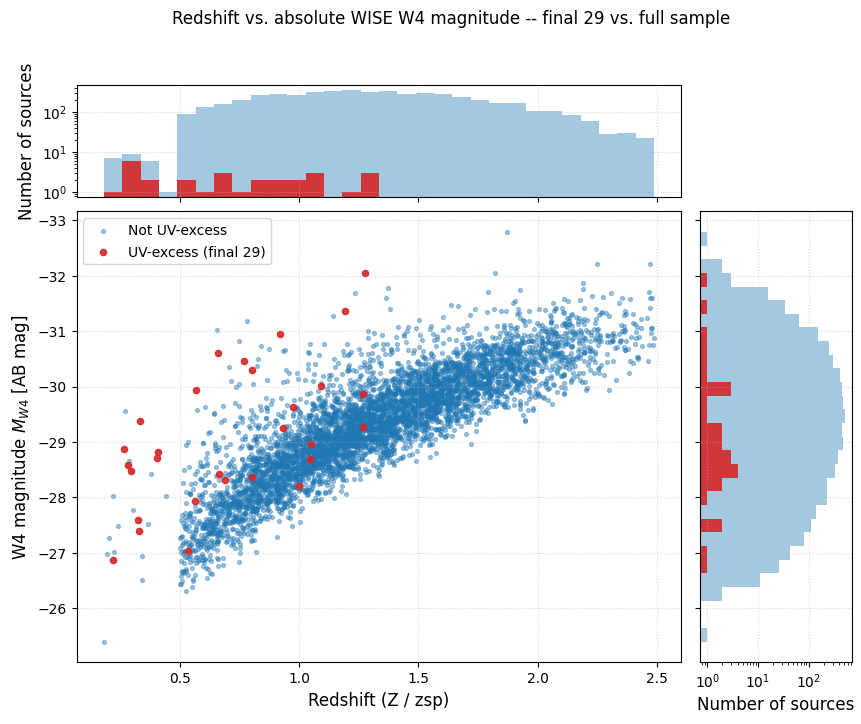

In [6]:
df_full = pd.read_csv(DATA_MATCHED / "FINAL_COMBINED_QSOs_W2M.csv", dtype={"TARGETID": "Int64"})
df_sample = pd.read_csv(SAMPLE_CSV, dtype={"TARGETID": "Int64"})

matched_by_id = df_full["TARGETID"].isin(df_sample["TARGETID"].dropna()) & df_full["TARGETID"].notna()
matched_by_designation = (
    df_full["designation"].isin(df_sample.loc[df_sample["TARGETID"].isna(), "designation"].dropna())
    & df_full["designation"].notna()
)
is_final = matched_by_id | matched_by_designation

W4_VEGA_TO_AB = 2.5 * np.log10(3631 / 8.363)  # SVO FPS zero point, ~6.594
z_full = df_full["Z"].where(df_full["Z"].notna(), df_full["zsp"])
w4_full = df_full["W4mag"].where(df_full["W4mag"].notna(), df_full["w4mag"]) + W4_VEGA_TO_AB

mask = z_full.notna() & w4_full.notna() & (z_full > 0)

cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)
lumdist = cosmo.luminosity_distance(z_full[mask].to_numpy())
distmod = 5 * np.log10(lumdist / u.Mpc) + 25
absW4 = w4_full[mask] - distmod

fig, axes = plt.subplots(
    2, 2, figsize=(10, 7.5),
    gridspec_kw={"width_ratios": [4, 1], "height_ratios": [1, 4], "wspace": 0.05, "hspace": 0.05},
)
ax_histx, ax_corner = axes[0]
ax, ax_hist = axes[1]
ax_hist.sharey(ax)
ax_histx.sharex(ax)
ax_corner.set_visible(False)

is_final_masked = is_final[mask]
ax.scatter(z_full[mask & ~is_final], absW4[~is_final_masked], s=8, alpha=0.4, color="tab:blue", label="Not UV-excess")
ax.scatter(z_full[mask & is_final], absW4[is_final_masked], s=20, alpha=0.9, color="tab:red", label="UV-excess (final 29)")
ax.set_xlabel("Redshift (Z / zsp)", fontsize=12)
ax.set_ylabel(r"W4 magnitude $M_{W4}$ [AB mag]", fontsize=12)
ax.invert_yaxis()
ax.grid(linestyle=":", alpha=0.5)
ax.legend(loc="best")

bins = np.histogram_bin_edges(absW4, bins=30)
ax_hist.hist(absW4, bins=bins, orientation="horizontal", color="tab:blue", alpha=0.4, label="All sources")
ax_hist.hist(absW4[is_final_masked], bins=bins, orientation="horizontal", color="tab:red", alpha=0.9, label="UV-excess")
ax_hist.set_xscale("log")
ax_hist.set_xlabel("Number of sources", fontsize=12)
ax_hist.grid(linestyle=":", alpha=0.5)
ax_hist.tick_params(labelleft=False)

zbins = np.histogram_bin_edges(z_full[mask], bins=30)
ax_histx.hist(z_full[mask], bins=zbins, color="tab:blue", alpha=0.4, label="All sources")
ax_histx.hist(z_full[mask & is_final], bins=zbins, color="tab:red", alpha=0.9, label="UV-excess")
ax_histx.set_yscale("log")
ax_histx.set_ylabel("Number of sources", fontsize=12)
ax_histx.grid(linestyle=":", alpha=0.5)
ax_histx.tick_params(labelbottom=False)

fig.suptitle("Redshift vs. absolute WISE W4 magnitude -- final 29 vs. full sample")
plt.savefig(FIGURES_DIR / "final_sample_z_w4.png", dpi=150)
plt.show()